# 0. Ambiente

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

# 1. Dados

In [2]:
df_consumo_mensal = pd.read_excel(
    '../../data/external/EPE/consumo_mensal/dados_abertos_consumo_mensal.xlsx',
    sheet_name="CONSUMO E NUMCONS SAM"
)

# 2. Pré-processamento

In [3]:
df_consumo_residencial = df_consumo_mensal[
    (df_consumo_mensal['Classe'] == 'Residencial')
    & (df_consumo_mensal['TipoConsumidor'] == 'Cativo')
].copy()

df_consumo_residencial['ConsumoConsumidores'] = df_consumo_residencial['Consumo'] / df_consumo_residencial['Consumidores']
df_consumo_residencial = df_consumo_residencial[['DataExcel', 'Regiao', 'Sistema', 'Consumo', 'Consumidores', 'ConsumoConsumidores']]

In [ ]:
regioes = df_consumo_residencial['Regiao'].unique()
regioes

In [236]:
# NOTE: Ano-Mes 201601 selecionado com base na estabilidade do consumo e consumo por consumores
df_consumo_sudeste = df_consumo_residencial[
    (df_consumo_residencial['Regiao'] == 'Sudeste')
    & (df_consumo_residencial['DataExcel'] >= '2015-01-01')
].copy()

In [237]:
# sns.lineplot(
#     df_consumo_sudeste,
#     x='DataExcel',
#     y='Consumo',
# )
# plt.show()

# sns.lineplot(
#     df_consumo_sudeste,
#     x='DataExcel',
#     y='Consumidores',
# )
# plt.show()

# sns.lineplot(
#     df_consumo_sudeste,
#     x='DataExcel',
#     y='ConsumoConsumidores',
# )
# plt.show()


# 3. Modelagem

In [238]:
def date_to_noam(date_series: pd.Series) -> pd.Series:
    """
    Converte coluna de datas para formato YYYYMM
    """
    return date_series.dt.strftime("%Y%m").astype(int)


def feature_covid(no_am_series: pd.Series):
    """
    Gera feature indicando período no qual ocorreu a pandemia da covid-19.
    """
    return no_am_series.between('2020-01-01', '2020-12-31').astype(int)

In [239]:
def gera_projecao_6m(
    prophet_model: Prophet,
    df_serie_temporal: pd.DataFrame,
    mes_limite: int,
    considera_covid: bool = False,
) -> pd.DataFrame:
    """
    Gera próximos 6 meses de consumo de energia elétrica residencial.

    Parâmetros
    ----------
    prophet_model : Modelo Prophet instanciado
    df_serie_temporal : DataFrame com dados a projetar
    mes_limite : Mês limite para treino do modelo, no formato 'yyyy-MM-01'
    """

    df_treino = df_serie_temporal[df_serie_temporal["ds"] <= mes_limite].copy()
    df_treino = df_treino[["ds", "y"]]

    if considera_covid:
        df_treino["COVID"] = feature_covid(df_treino["ds"])
        prophet_model.add_regressor("COVID", mode="additive")

    prophet_model.fit(df_treino)

    # Projetando N meses a frente
    future = prophet_model.make_future_dataframe(periods=6, freq="MS", include_history=False)

    if considera_covid:
        future["COVID"] = feature_covid(future["ds"])

    forecast = prophet_model.predict(future)
    forecast = forecast[["ds", "yhat"]]

    return forecast

In [240]:
df_serie_sudeste = df_consumo_sudeste.rename(columns={"DataExcel": "ds", "Consumo": "y"})[['ds', 'y']]
df_serie_sudeste = df_serie_sudeste.sort_values("ds")

meses_limite = [f"{ano}-{mes:02}-01" for ano in range(2018, 2024+1) for mes in [6,12]]
meses_limite = meses_limite[:-1]

print("Meses para validação cruzada:",meses_limite)

Meses para validação cruzada: ['2018-06-01', '2018-12-01', '2019-06-01', '2019-12-01', '2020-06-01', '2020-12-01', '2021-06-01', '2021-12-01', '2022-06-01', '2022-12-01', '2023-06-01', '2023-12-01', '2024-06-01']


In [250]:
df_projecao_sudeste = pd.DataFrame()
for mes in meses_limite:

    modelo_consumo = Prophet(growth="linear", seasonality_mode="additive", yearly_seasonality=5)

    _df_projecao_sudeste = gera_projecao_6m(
        modelo_consumo,
        df_serie_sudeste,
        mes_limite=mes,
        considera_covid=False
    )

    df_projecao_sudeste = pd.concat([df_projecao_sudeste, _df_projecao_sudeste])



12:33:15 - cmdstanpy - INFO - Chain [1] start processing
12:33:15 - cmdstanpy - INFO - Chain [1] done processing
12:33:15 - cmdstanpy - INFO - Chain [1] start processing
12:33:15 - cmdstanpy - INFO - Chain [1] done processing
12:33:15 - cmdstanpy - INFO - Chain [1] start processing
12:33:15 - cmdstanpy - INFO - Chain [1] done processing
12:33:16 - cmdstanpy - INFO - Chain [1] start processing
12:33:16 - cmdstanpy - INFO - Chain [1] done processing
12:33:16 - cmdstanpy - INFO - Chain [1] start processing
12:33:16 - cmdstanpy - INFO - Chain [1] done processing
12:33:16 - cmdstanpy - INFO - Chain [1] start processing
12:33:16 - cmdstanpy - INFO - Chain [1] done processing
12:33:16 - cmdstanpy - INFO - Chain [1] start processing
12:33:17 - cmdstanpy - INFO - Chain [1] done processing
12:33:17 - cmdstanpy - INFO - Chain [1] start processing
12:33:17 - cmdstanpy - INFO - Chain [1] done processing
12:33:17 - cmdstanpy - INFO - Chain [1] start processing
12:33:18 - cmdstanpy - INFO - Chain [1]

In [251]:
df_results = df_serie_sudeste.merge(df_projecao_sudeste, on='ds')
df_results['ERRO_ABS'] = np.abs(df_results['y'] - df_results['yhat'])
df_results['ERRO_ABS_PCT'] = df_results['ERRO_ABS'] / df_results['y']

wmape = df_results['ERRO_ABS'].sum() / df_results['y'].sum()
mape = df_results['ERRO_ABS_PCT'].mean()

print(f"WMAPE: {wmape*100:.2f}%", f"MAPE: {mape*100:.2f}%")

WMAPE: 3.96% MAPE: 3.86%


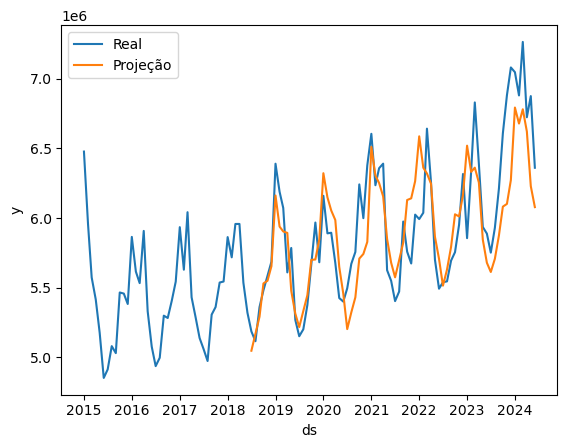

In [252]:
sns.lineplot(
    df_serie_sudeste,
    x='ds',
    y='y',
    label='Real'
)

sns.lineplot(
    df_results,
    x='ds',
    y='yhat',
    label='Projeção'
)

plt.show()

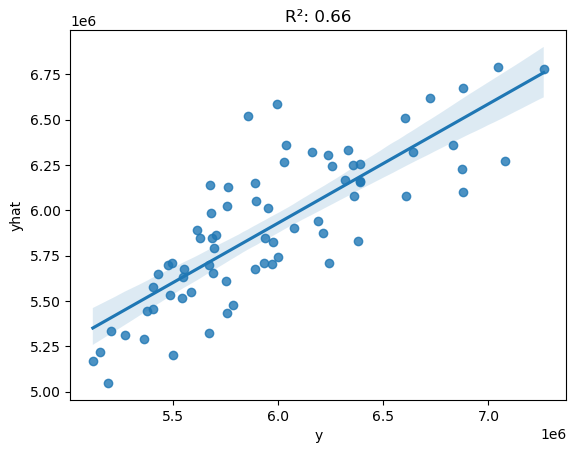

In [264]:
from scipy import stats
r2 = stats.pearsonr(df_results['y'], df_results['yhat'])[0]**2

linear = sns.regplot(df_results, x='y', y='yhat')
linear.set_title(f"R²: {r2:.2f}")
plt.show()